### Setup GoogleColab environment

Install hylite and download tutorial data

In [1]:
# download demo dataset (https://drive.google.com/file/d/1X8xR1LxB7VR_JuvdmDwqJXeSILr9LP-n/view?usp=drive_link)
# https://drive.google.com/file/d/1X8xR1LxB7VR_JuvdmDwqJXeSILr9LP-n/view?usp=sharing
!gdown 1X8xR1LxB7VR_JuvdmDwqJXeSILr9LP-n
!unzip demo_data.zip

from IPython.display import clear_output
clear_output() # clear output (it isn't easy being clean!)

In [ ]:
# install hylite

! pip install git+https://github.com/hifexplo/hylite.git
clear_output() # clear output (it isn't easy being clean!)

In [ ]:
import hylite
import numpy as np

In [ ]:
%matplotlib inline

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 1. Data types

Hyperspectral data can take many forms. *hylite* uses polymorphic data structures to make analyses as generic and as smooth as possible, such that most analyses conducted on e.g. image data can also be executed on e.g. hypercloud data.

Generally speaking, hyperspectral data comes in two forms: (1) spectral lists (e.g. spectral libraries, hyperclouds), or (2) spectral data cubes (e.g., hyperspectral images). *hylite* thus implements a generic `HyData` class that implements basic functions that are independent of spectral dimension, which is then extended in child classes to add specific functionality for different hyperspectral data types. These are:

* HyImage - for hyperspectral image cubes.
* HyCloud - for hypercloud data (spectra associated with spatially located points).
* HyLibrary - for spectral library data.

Additionally, collections of hyperspectral and associated data (e.g., geometry, illumination properties etc.) often need to be grouped together. This is simplified in *hylite* using a directory-like data structure *HyCollection* and its inheriting classes.

In the following examples we will explore these data types and simple ways to interact with them.

----

**Exercise:** *Explore the documentation for the different data objects using the `?` operator*

In [ ]:
import hylite
from hylite import HyData, HyImage, HyCloud, HyLibrary, HyHeader, HyCollection, HyScene

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
HyImage?

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 2. Loading data

Functions for loading and saving data a variety of data types are implemented in the *hylite.io* package. To keep your code simple, these can all be called via the generic *io.load* and *io.save* functions in most situations. File formats that can be read / written this way include:

* **images**: *ENVI, .jpg, .png, .bmp, .tiff*
* **point clouds**: *.ply, .laz* ( [CloudCompare](https://cloudcompare.org/) is a handy open-source tool for converting / manipulating point cloud data ). Hyperclouds with associated scalar data (e.g. spectra, geometric attributes etc.) can be stored in *.ply* format.
* **HyCollection** and **HyScene** directories: *.hyc, .hys*
* header files: *.hdr* (though note that data associated with a *.hdr* file will be loaded also; use load_header to open only the header file)
* **spectral libraries**: *.csv, .sed*
* **numpy arrays**: *.npy*

-------------

 **Exercise:** Load some different file types.

In [ ]:
# import IO functionality
from hylite import io

# open an ENVI image
image = io.load( 'test_data/image.hdr' )

# open a .ply point cloud
cloud = io.load( 'test_data/hypercloud.ply' )
cloud.decompress() # this was compressed from float to integer to save space; so we need to convert it back

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 3. Metadata and header files

In keeping with the standard ENVI file format, metadata associated with hyperspectral datasets (e.g. band widths and wavelengths, acquisition parameters, etc.) can be stored in a simple text header (.hdr) file. We have extended  the amount of information that can be stored in headers to include e.g. calibration panel data (see *hylite.header.get_panel*) and camera pose information (see *hylite.header.get_camera*).

All *hylite* data objects have a `foo.header` attribute that provides access to header data. This inherits from pythons inbuilt dictionary type, so specific keywords can be accessed or set using `foo.header['some_param']`. Note that keys and values in this dictionary are both stored as text (at least when the header is written to disk), so data types such as arrays need to be parsed using the appropriate function (e.g. *header.get_list*).

----

**Exercise:** View header file contents and add / remove keys.

In [ ]:
cloud.header.print() # view the keys and associated data stored in the header file

file type = { Hypercloud } 
path = { test_data/hypercloud.hdr } 
wavelength = { [2115.62 2121.12 2126.63 2132.13 2137.64 2143.14 2148.64 2154.14 2159.64
 2165.14 2170.64 2176.13 2181.63 2187.12 2192.61 2198.1  2203.59 2209.08
 2214.57 2220.06 2225.54 2231.03 2236.51 2241.99 2247.48 2252.96 2258.44
 2263.91 2269.39 2274.87 2280.34 2285.81 2291.28 2296.76 2302.23 2307.69
 2313.16 2318.63 2324.09 2329.56 2335.02 2340.48 2345.94 2351.4  2356.86
 2362.31 2367.77 2373.22 2378.67 2384.12] } 
camera 0 pose = { 711677.000000 4174777.000000 300.000000 -92.000000 -30.000000 0.000000 } 
camera 0 internals = { persp 500 250 12.000000 } 
samples = { 354313 } 
bands = { 50 } 
lines = { 1 } 
wavelength units = { nm } 
reflectance scale factor = { 1.0 } 


In [ ]:
#access data stored in the header file. Note that this is a string.
print(cloud.header['bands'], type(cloud.header['bands']))
assert int(cloud.header['bands']) == cloud.band_count() # check value in header matches number of bands in dataset

50 <class 'str'>


In [ ]:
# get a list from the header file as a numpy array
wav = cloud.header.get_list('wavelength')
print("Hyperspectral bands range from: %s nm - %s nm" %( np.min(wav), np.max(wav)) )

Hyperspectral bands range from: 2115.62 nm - 2384.12 nm


In [ ]:
# get camera pose information from the header file
cam = cloud.header.get_camera(0)
print("Sensor position is [%.1f,  %.1f,  %.1f] m" % tuple(cam.pos))

Sensor position is [711677.0,  4174777.0,  300.0] m


In [ ]:
# Add some random information to the header
cloud.header['myname'] = 'Chuck'
cloud.header['wavenumber'] = 1. / (wav*1e-7)

In [ ]:
cloud.header.print()

file type = { Hypercloud } 
path = { test_data/hypercloud.hdr } 
wavelength = { [2115.62 2121.12 2126.63 2132.13 2137.64 2143.14 2148.64 2154.14 2159.64
 2165.14 2170.64 2176.13 2181.63 2187.12 2192.61 2198.1  2203.59 2209.08
 2214.57 2220.06 2225.54 2231.03 2236.51 2241.99 2247.48 2252.96 2258.44
 2263.91 2269.39 2274.87 2280.34 2285.81 2291.28 2296.76 2302.23 2307.69
 2313.16 2318.63 2324.09 2329.56 2335.02 2340.48 2345.94 2351.4  2356.86
 2362.31 2367.77 2373.22 2378.67 2384.12] } 
camera 0 pose = { 711677.000000 4174777.000000 300.000000 -92.000000 -30.000000 0.000000 } 
camera 0 internals = { persp 500 250 12.000000 } 
samples = { 354313 } 
bands = { 50 } 
lines = { 1 } 
wavelength units = { nm } 
reflectance scale factor = { 1.0 } 
myname = { Chuck } 
wavenumber = { [4726.74676927 4714.49045787 4702.27543108 4690.14553522 4678.0561741
 4666.05074797 4654.10678383 4642.22381089 4630.40136319 4618.63897947
 4606.93620315 4595.31369909 4583.72867993 4572.22283185 4560.77460196
 4549

Note that these values will be saved on calling *io.save(...)*, providing an easy way to create persistent metadata.

----
### 4. Hyperspectal data arrays

Most hyperspectral analyses require some form of custom data munging, so the raw hyperspectral data arrays are left very exposed in *hylite*. Any `HyData` instance (including e.g. `HyImage` or `HyCloud` datasets) have a `foo.data` numpy array that contains the raw spectra. This provides easy access for processing, but can also make it easy to corrupt datasets - so use with care!

The shape of the data array will vary from 2-D (id, band) for spectral libraries and hyperclouds to 3-D (x,y,band) for image cubes.

In [ ]:
print(cloud.data.shape, "= (pointID, bandID)")

(354313, 50) = (pointID, bandID)


In [ ]:
print(image.data.shape, "= (x,y,bandID)")

(269, 87, 55) = (x,y,bandID)


In [ ]:
image.data[ np.isnan( image.data ) ] = 0 # data arrays can be directly modified. Do this with care!

------
**Important note:** Hyperspectral bands can be referenced based on either their index (e.g. band number 10), or by the wavelength specified in the image metadata (e.g. 1000 nm).

To seamlessly distinguish these two methods, hylite treats integer values (e.g., 1, 2, 1000) as indices and floating point values (e.g. 450.0, 750.0, 1000.0) as wavelengths (in the units defined in the header file, which are normally nanometers).

**TLDR: Integers represent indices, floating point values represent wavelengths.**

----

Wavelengths can be converted to band indices using the `get_band_index` function, which returns the closest band to the specified wavelength.

In [ ]:
print("Index of 2200. nanometers in hypercloud:", cloud.get_band_index(2200.0))

Index of 2200. nanometers in hypercloud: 15


In [ ]:
print("Index of 2200. nanometers in image:", image.get_band_index(2200.0))


Index of 2200. nanometers in image: 18


Similarly, band indexes can be converted to wavelengths using the get_wavelengths() function, which returns an array containing the wavelength for each band.

In [ ]:
print( image.get_wavelengths()[18])

2198.1


Note that an error will be thrown if the difference between the requested wavelength and closest entry in the wavelength array is too large. This tolerance can be adjusted using the global *hylite.band_select_threshold* value.

In [ ]:
print( "Provided wavelengths must be within %.1f nm of existing bands." % hylite.band_select_threshold )
#image.get_band_index( 2410. ) # throws an error
hylite.band_select_threshold = 20
image.get_band_index( 2410. ) # does not throw an error

Provided wavelengths must be within 10.0 nm of existing bands.


54

Hyperclouds have several additional data arrays containing geometric attributes and (if defined) point colours and normal vectors. These can be accessed using:
* `foo.xyz` (point positions)
* `foo.rgb` (point colours from e.g. SfM model, if defined)
* `foo.normals` (point normals, if defined)

In [ ]:
print("Point #10 colour: ", cloud.rgb[10,:])
print("Point #10 normal: ", cloud.normals[10,:])
print("Point #10 position: ", cloud.xyz[10,:])

Point #10 colour:  [191 147 107]
Point #10 normal:  [-0.00120347 -0.9639813   0.26596737]
Point #10 position:  [7.11248290e+05 4.17580628e+06 2.55039993e+02]


### 5. Quick plotting

Visualisation will be covered in detail in a subsequent notebook, but the quick_plot(...) provides a good example
for the flexibility provided by these different indexing methods.

-----

In [ ]:
print( hylite.SWIR ) # some preset bands for false-colour visualisation with SWIR data. Note the floating point.

(2200.0, 2250.0, 2350.0)


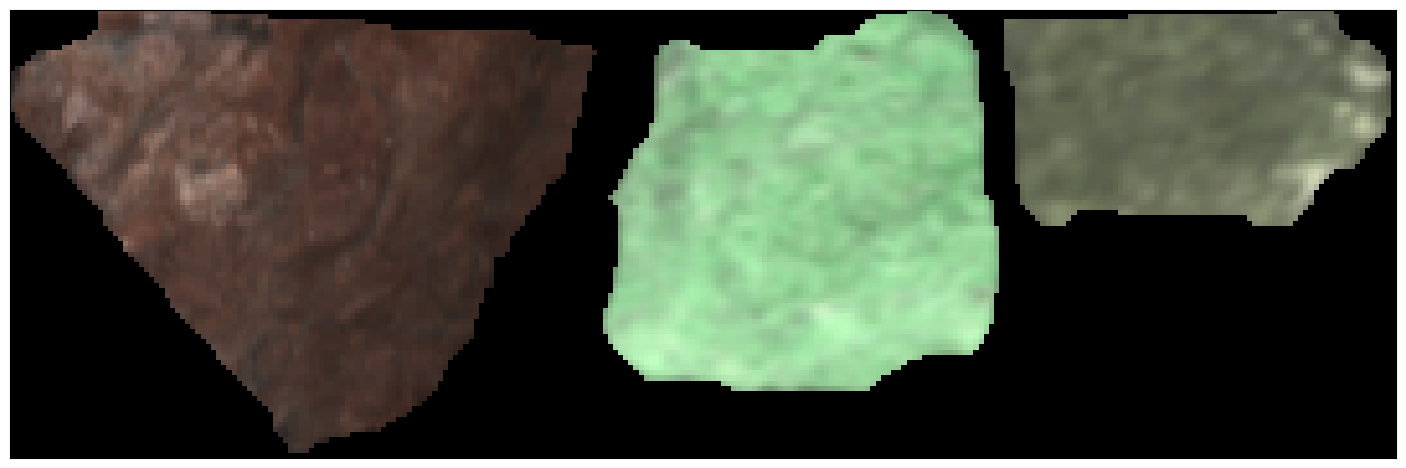

In [ ]:
fig,ax = image.quick_plot(hylite.SWIR)
fig.show()

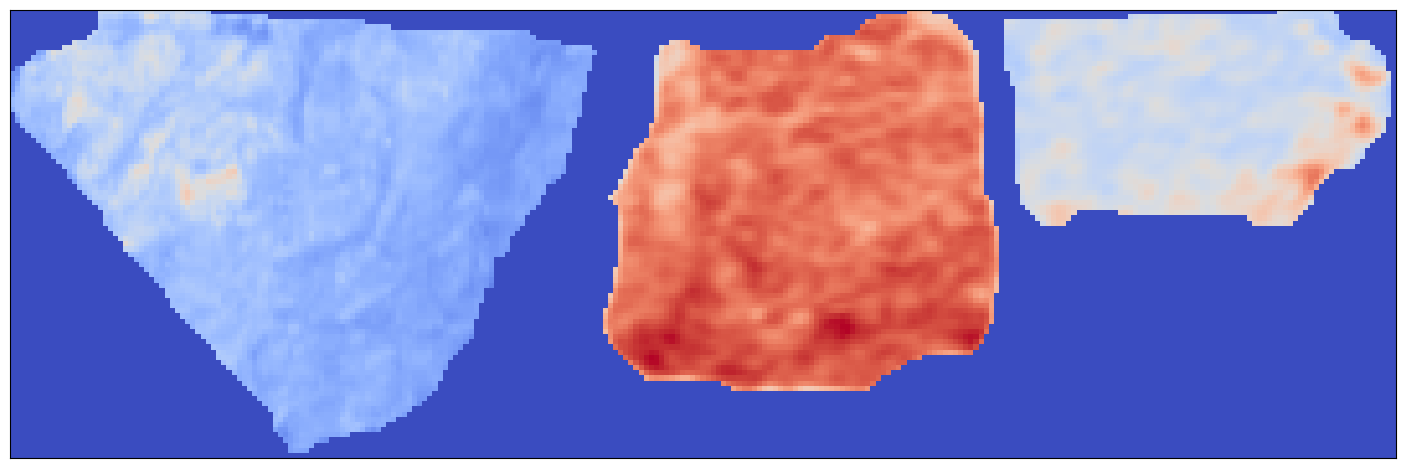

In [ ]:
fig,ax = image.quick_plot( 0, cmap='coolwarm' ) # plot with band index
fig.show()

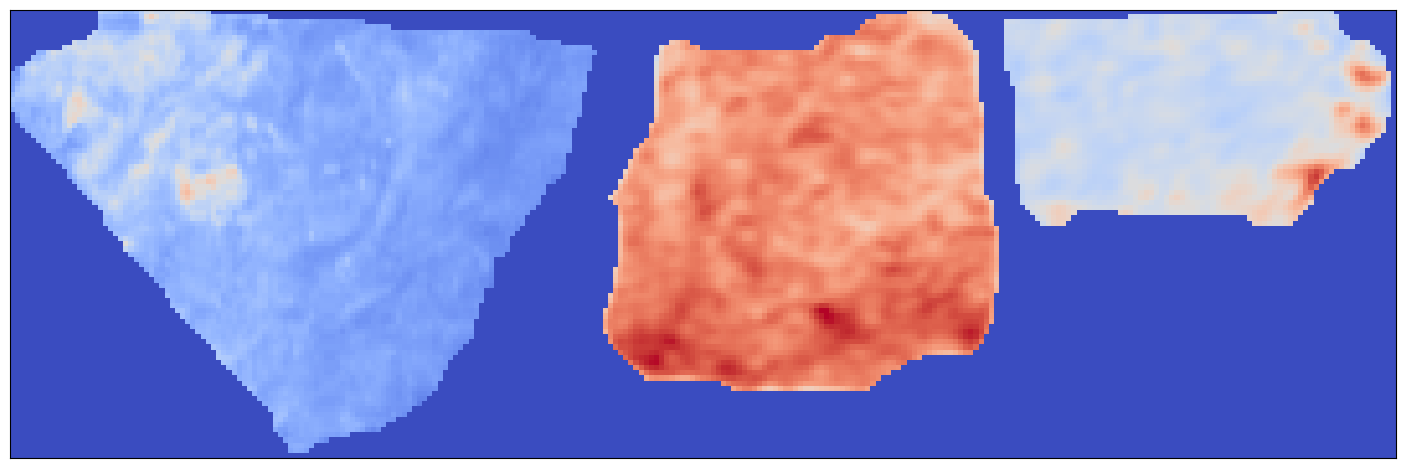

In [ ]:
fig,ax = image.quick_plot( 2340., cmap='coolwarm' ) # plot with wavelength
fig.show()

----

Unlike images, hyperclouds can have per-point colours that are independent of the hyperspectral data (e.g. based on the SfM pointcloud used to capture hypercloud geometry). These can be accessed by plotting `'rgb'`.

----

**Exercise**: *Experiment with 'rgb', 'klm' (normal vectors) and 'xyz' colour renders. Also try rearranging the orders of the letters to generate different colour mappings*

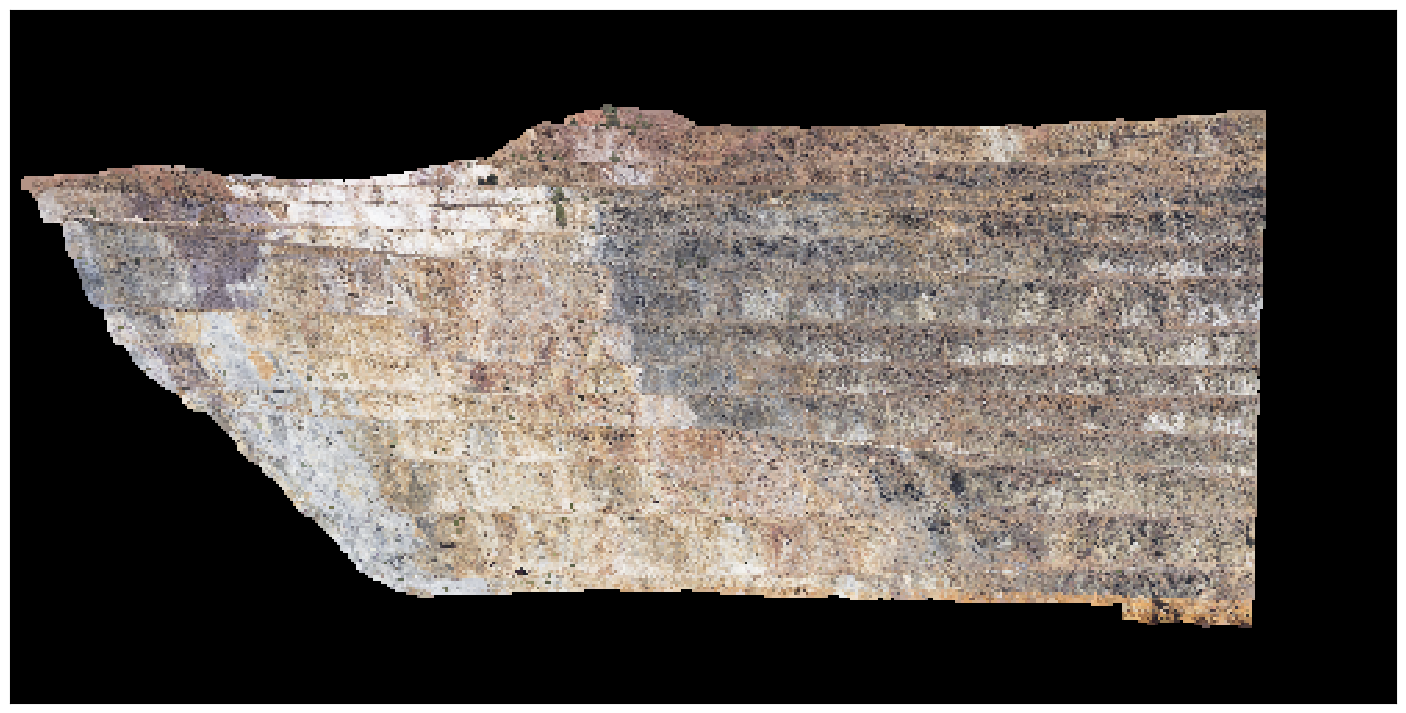

In [ ]:
fig,ax = cloud.quick_plot('rgb', cloud.header.get_camera(0), fill_holes=True)
fig.show()

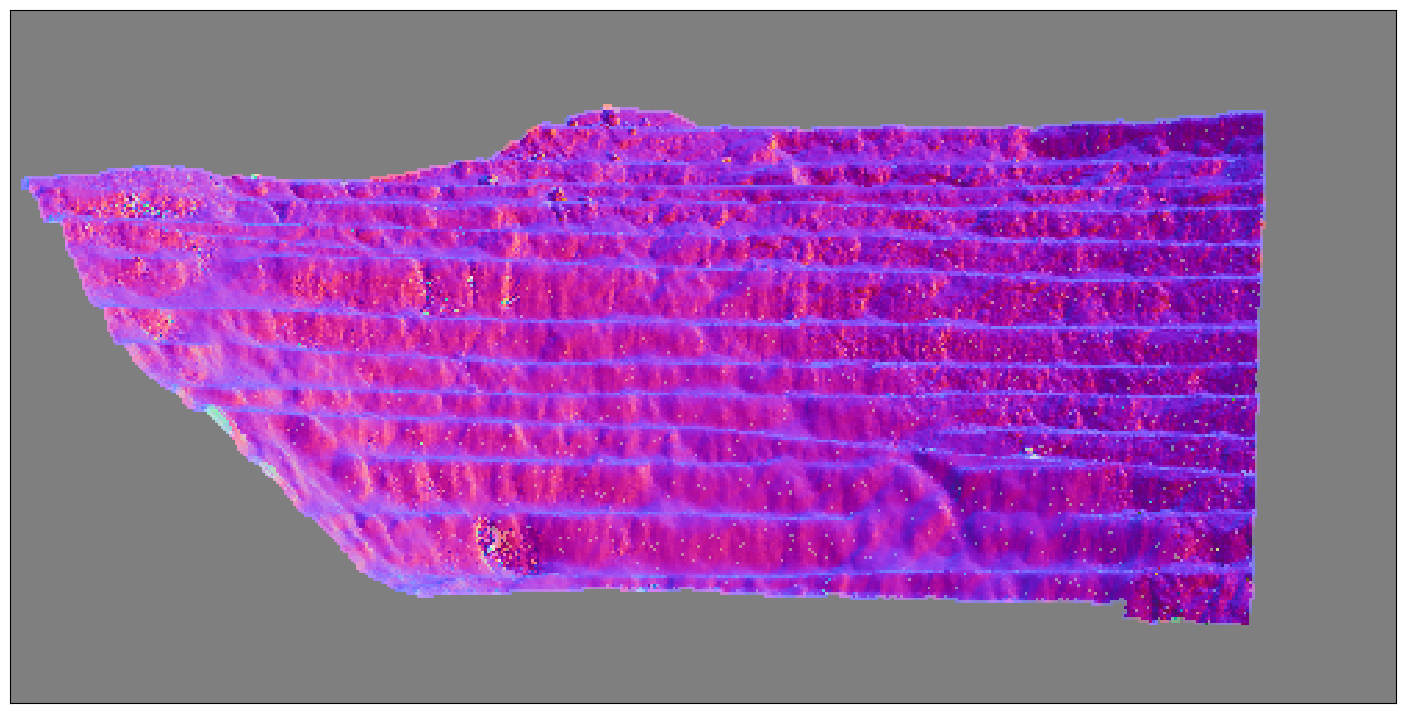

In [ ]:
fig,ax = cloud.quick_plot('klm',cloud.header.get_camera(0), fill_holes=True)
fig.show()

Arbitrary visualisations of individual or ternary band combinations can also be easily created using *quick_plot*. Some convenient ternary combinations are included in `hylite.SWIR` and (if you have LWIR data) `hylite.LWIR`.

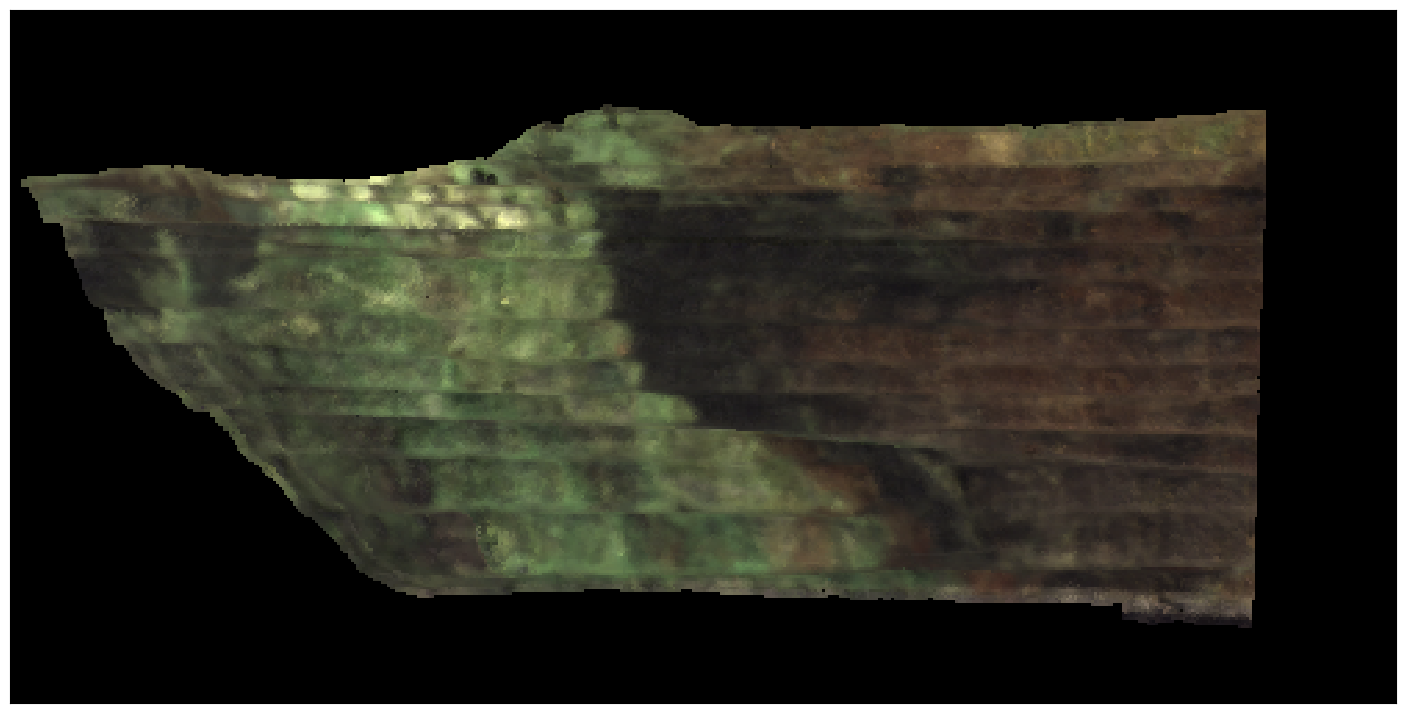

In [ ]:
fig,ax = cloud.quick_plot(hylite.SWIR, cloud.header.get_camera(0), fill_holes=True )
fig.show()


----

**Exercise:** *Use the data visualisation tools to see if you can guess where in the hypercloud scene the rock samples pictured above (in the `image` variable) come from.*



In [ ]:
# your funky code here!

----

### 6. Spectral libraries and spectral caterpillars  🐛


It is often convenient to quickly summarise all of the spectra in a dataset. This can be done using the `foo.plot_spectra` function, which generates a *spectral caterpillar* defined by the median (black) and 5th, 25th, 75th and 95th percentiles of each band (grey envelopes). Specific point or pixel spectra can also be added using the `indices` argument.

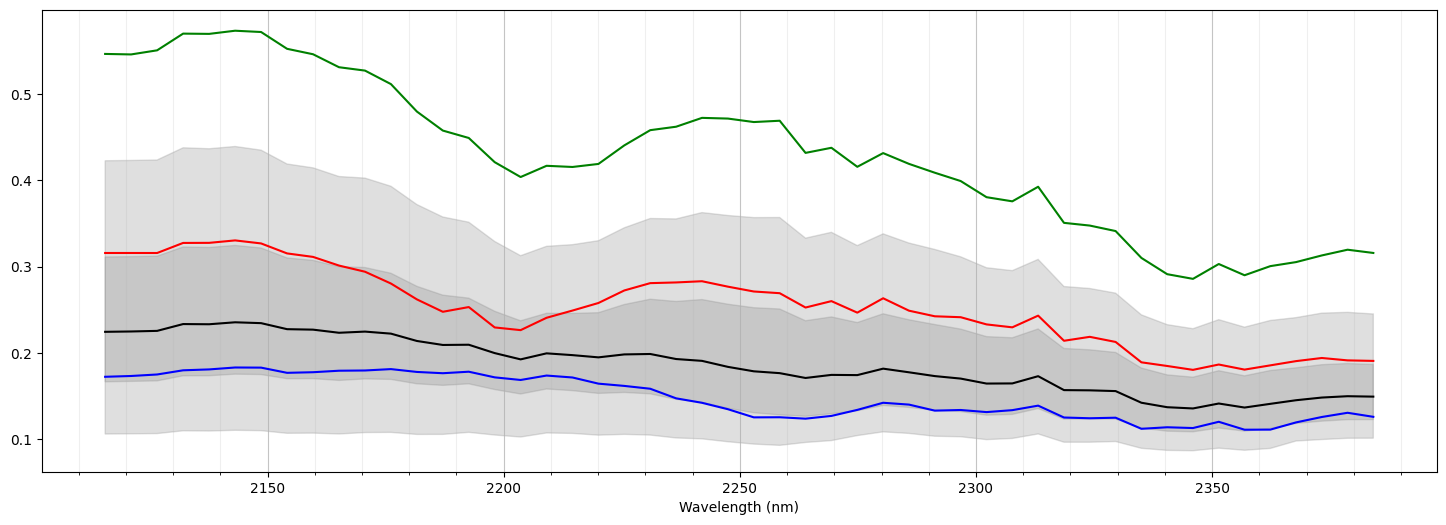

In [ ]:
# plot a basic spectral caterpillar
fig,ax = cloud.plot_spectra(indices=[108113,82475,326198], colours=['r','g','b'])
fig.show()

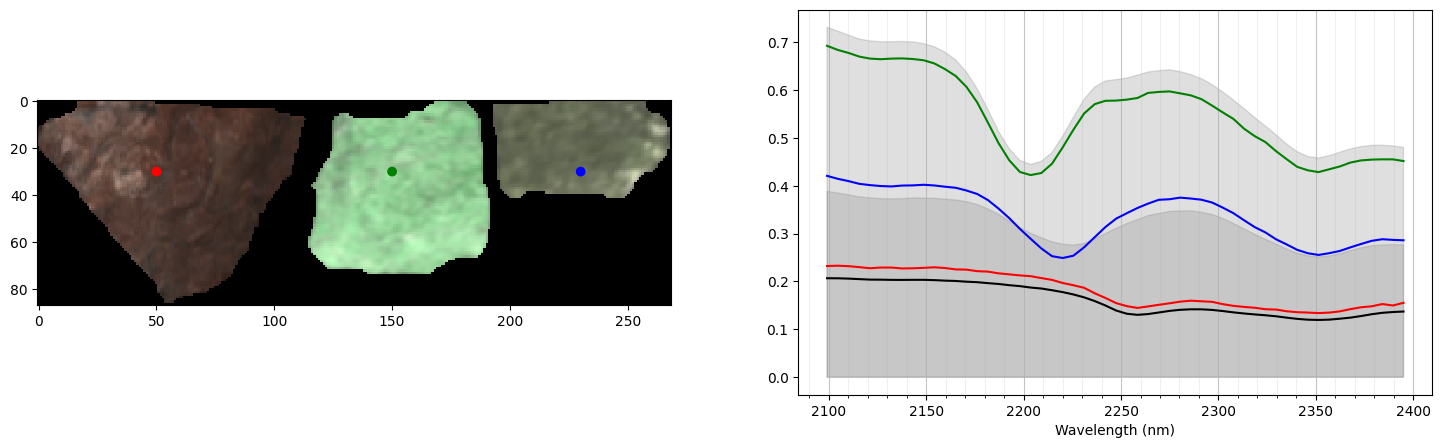

In [ ]:
# plot image and associated spectra
pixels = [(50,30), (150,30), (230,30)]

import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2,figsize=(18,5))
image.quick_plot(hylite.SWIR, ax=ax[0], ticks=True) # plot image to existing axes object, and plot x- and y- coords
ax[0].scatter([p[0] for p in pixels], [p[1] for p in pixels], color=['r','g','b'])

# add a spectral caterpillar
image.plot_spectra(band_range=(2100.,2400.), indices=pixels, colours=['r','g','b'], ax=ax[1])
fig.show()

Spectral libraries can also be loaded and plotted for reference. These will be explored in detail in a subsequent notebook.

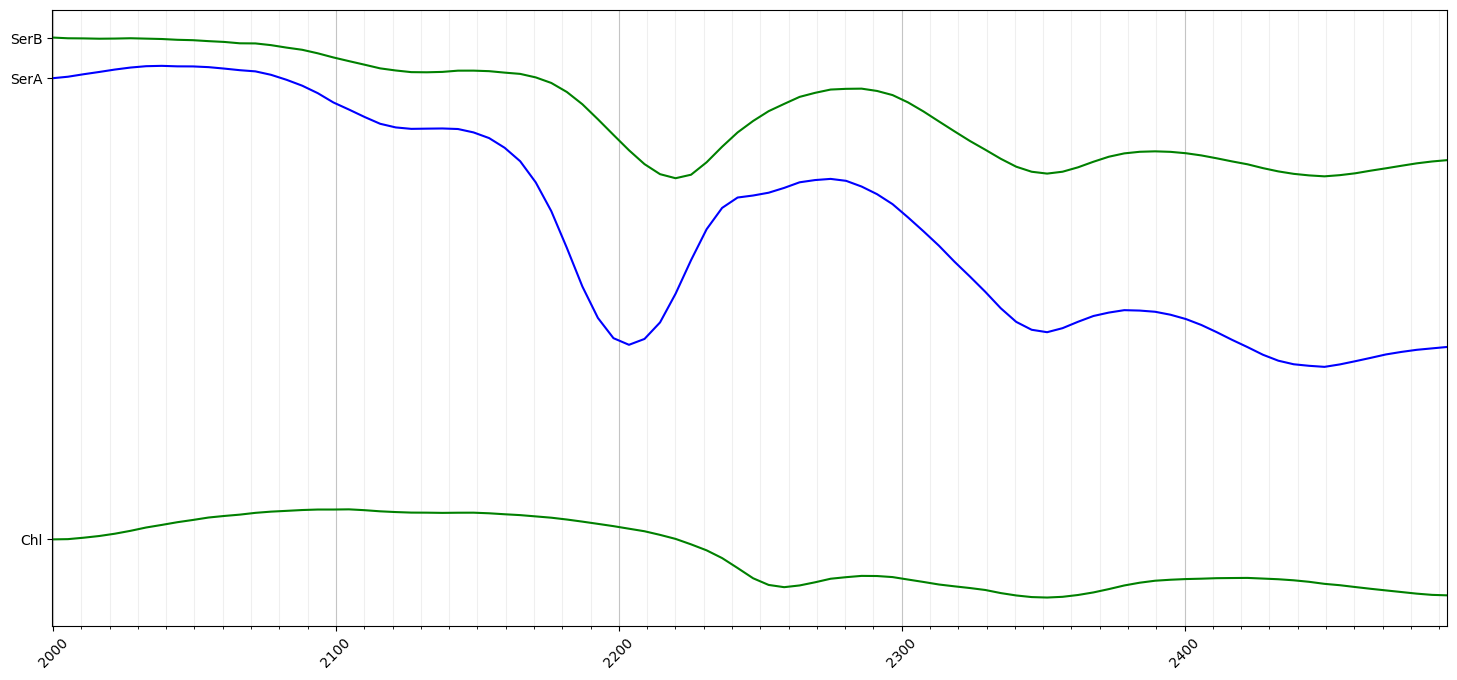

In [ ]:
lib = io.load( 'test_data/library.csv' )
fig,ax = lib.quick_plot(band_range=(2000.,2500.))
fig.show()

### 7. Saving results

Finally, once some form of processing has been achieved, data can be saved using the `io.save` function. This automatically determines the data type and generates the appropriate files.

In [ ]:
io.save?

In [ ]:
out = image.copy() # make a copy of the dataset as otherwise we modify it inplace
out.data = 1.0 - image.data # apply some voodoo magic

# save our processed dataset
io.save( './outputs/rocks.hdr', out )

### 8. Organising data using *HyCollection*

It is often also desirable to organise multiple related datasets (hyperspectral and otherwise) into one data structure. This can be achieved using the *HyCollection* instance, which provides an easy mapping between a directory storing data and variables in Python that you can load, manipulate and save. While potentially overly complex for simple datasets, *HyCollections* facilitate simpler IO operations when processing large numbers of hyperspectral images, and allow easier management of often-limited RAM (out-of-core like processing).

In [ ]:
from hylite import HyCollection

# initialise a collection
C = HyCollection("MyCollection", "./outputs" )

# put some data in it
C.image = image
C.image_adj = out
C.cloud = cloud
C.random_array = np.random.rand(100) # N.B. this will be stored as an .npy file
C.magicvalue = 42 # N.B. this will be stored in the HyCollection's header file
C.astring = 'foo' # And so will this

# save everything!
C.save() # n.b. you can also save a collection to a different folder using io.save('somepath', C)

Once created, data in a HyCollection can be easily reloaded using *io.load(...)*. Note that to save memory, each attribute of the HyCollection will not actually be loaded into memory until it is accessed the first time.

In [ ]:
C2 = io.load('./outputs/MyCollection.hdr')

In [ ]:
C2.print() # see what is in this collection, and note that no data has actually been loaded yet


Attributes stored in RAM:
Attributes stored in header:
	 magicvalue = <class 'str'>
	 astring = <class 'str'>
Attributes stored on disk:
	 - cloud.ply
	 - random_array.npy
	 - image.dat
	 - image_adj.dat


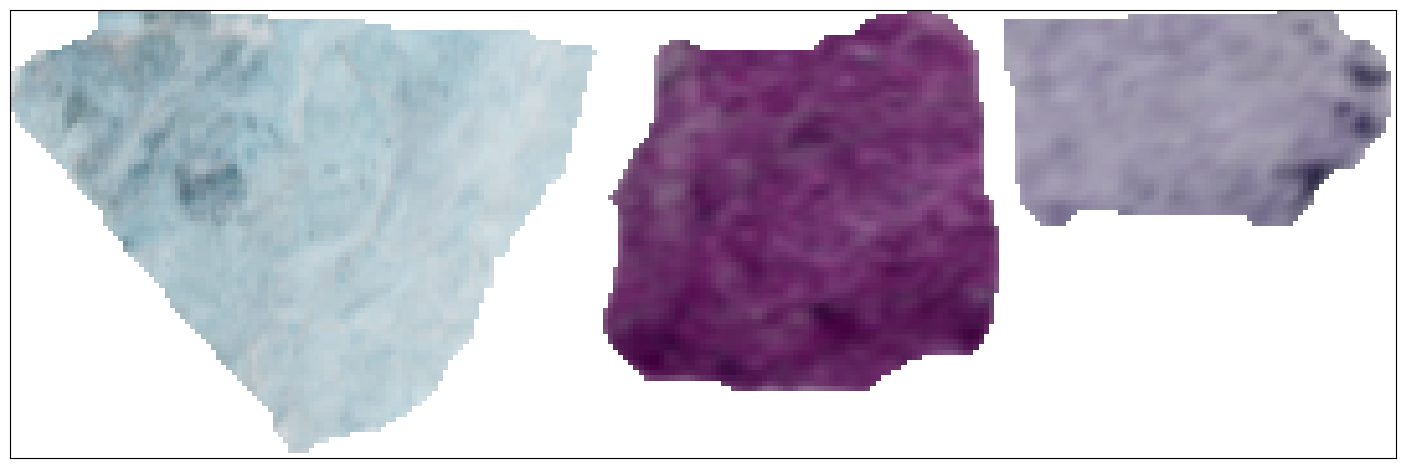

In [ ]:
# access an attribute (and load it into memory)
fig,ax = C2.image_adj.quick_plot( hylite.SWIR )
fig.show()

In [ ]:
C2.print() # the image has now been loaded into RAM

Attributes stored in RAM:
	 - <class 'hylite.hyimage.HyImage'> called image_adj
Attributes stored in header:
	 magicvalue = <class 'str'>
	 astring = <class 'str'>
Attributes stored on disk:
	 - cloud.ply
	 - random_array.npy
	 - image.dat
